In [4]:
%pip install skyfield
%pip install matplotlib

Tue Apr  7 16:09:11 CDT 2026
Defaulting to user installation because normal site-packages is not writeable
  Using cached skyfield-1.54-py3-none-any.whl (370 kB)
     |████████████████████████████████| 153 kB 10.3 MB/s eta 0:00:01
  Using cached jplephem-2.24-py3-none-any.whl (49 kB)
     |████████████████████████████████| 235 kB 69.7 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
Tue Apr  7 16:09:15 CDT 2026
Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (7.6 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Usi

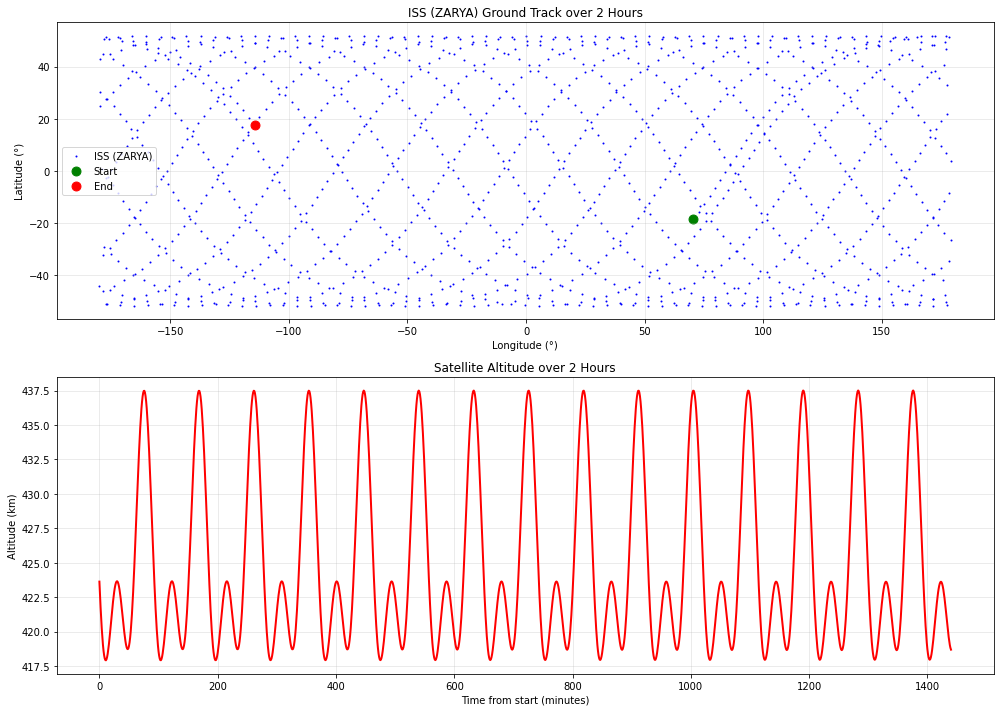

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, wgs84, EarthSatellite
from datetime import datetime, timedelta

# ==================== CONFIG ====================
# Paste your TLE here (Line 0 optional, Line 1 and Line 2 required)
tle_lines = [
    "ISS (ZARYA)",
    "1 25544U 98067A   26097.12345678  .00001534  00000-0  35580-4 0  9999",
    "2 25544  51.6416 247.4627 0001671  64.9808 295.1027 15.49338189 99999"
]

satellite_name = tle_lines[0].strip()
line1 = tle_lines[1]
line2 = tle_lines[2]

# Time range: now + 2 hours, with 1-minute steps
ts = load.timescale()
t0 = ts.now()                                   # current UTC time
t1 = ts.utc(t0.utc_datetime() + timedelta(hours=24))  # 24 hours later

# Create evenly spaced times (every 60 seconds)
numpts = int((t1.utc_datetime() - t0.utc_datetime()).total_seconds() / 60) + 1
times = ts.linspace(t0, t1, num=numpts)            # 121 points = 2 hours at 1-min interval

# ==================== COMPUTE POSITIONS ====================
satellite = EarthSatellite(line1, line2, satellite_name, ts)

# Get geocentric position at all times
geocentric = satellite.at(times)

# Convert to latitude, longitude, and height (km)
lat = wgs84.latlon_of(geocentric)[0].degrees
lon = wgs84.latlon_of(geocentric)[1].degrees
height_km = wgs84.height_of(geocentric).km

# ==================== PLOTS ====================

plt.figure(figsize=(14, 10))

# Plot 1: Ground Track (Latitude vs Longitude)
plt.subplot(2, 1, 1)
plt.scatter(lon, lat, c='blue', s=1, label=satellite_name)
plt.scatter(lon[0], lat[0], color='green', s=80, label='Start')
plt.scatter(lon[-1], lat[-1], color='red', s=80, label='End')

plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.title(f'{satellite_name} Ground Track over 2 Hours')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Altitude over Time
plt.subplot(2, 1, 2)
minutes = np.linspace(0, numpts - 1, len(times))   # minutes from start
plt.plot(minutes, height_km, 'r-', linewidth=2)
plt.xlabel('Time from start (minutes)')
plt.ylabel('Altitude (km)')
plt.title('Satellite Altitude over 2 Hours')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

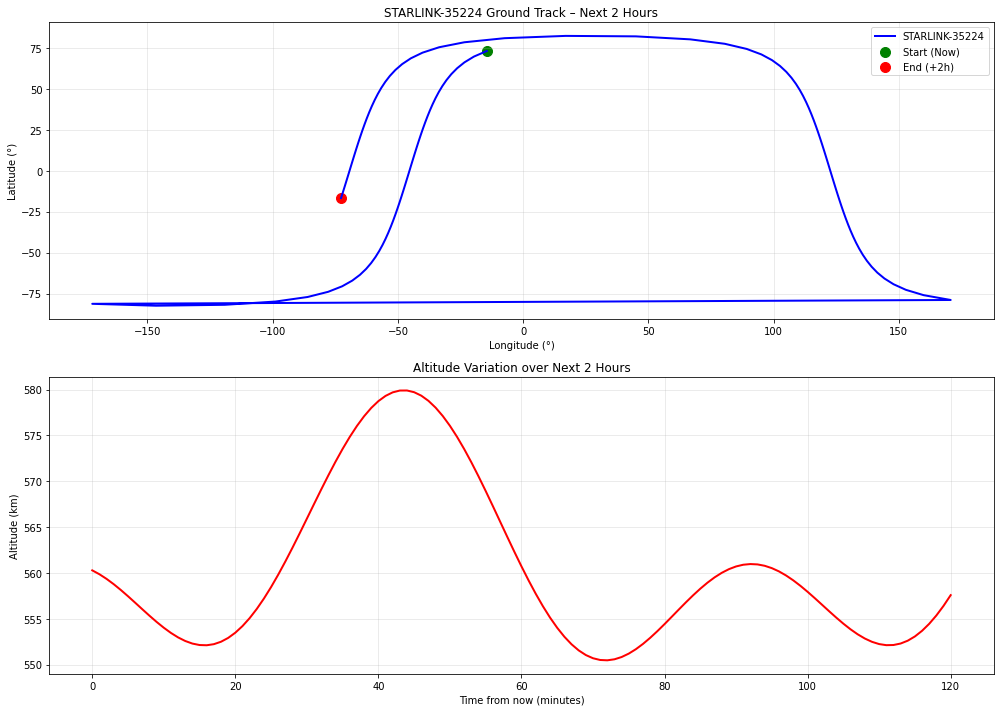

In [12]:
# ==================== TLE DATA ====================
tle_lines = [
    "STARLINK-35224",
    "1 65811U 25218W   26097.60955005  .00006254  00000-0  43716-3 0  9994",
    "2 65811  97.6024 321.4932 0003219  68.8995 291.2576 15.05655268 29326"
]

# Load timescale and create satellite object
ts = load.timescale()
satellite = EarthSatellite(tle_lines[1], tle_lines[2], tle_lines[0], ts)

# Time range: now → now + 2 hours (every 60 seconds)
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(hours=2))
times = ts.linspace(t0, t1, num=121)   # 121 points = 2 hours @ 1 min steps

# Compute positions
geocentric = satellite.at(times)
lat = wgs84.latlon_of(geocentric)[0].degrees
lon = wgs84.latlon_of(geocentric)[1].degrees
height_km = wgs84.height_of(geocentric).km

# ==================== PLOTS ====================
plt.figure(figsize=(14, 10))

# Ground Track
plt.subplot(2, 1, 1)
plt.plot(lon, lat, 'b-', linewidth=2, label='STARLINK-35224')
plt.scatter(lon[0], lat[0], color='green', s=100, label='Start (Now)')
plt.scatter(lon[-1], lat[-1], color='red', s=100, label='End (+2h)')

plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.title('STARLINK-35224 Ground Track – Next 2 Hours')
plt.grid(True, alpha=0.3)
plt.legend()

# Altitude over time
plt.subplot(2, 1, 2)
minutes = np.linspace(0, 120, len(times))
plt.plot(minutes, height_km, 'r-', linewidth=2)
plt.xlabel('Time from now (minutes)')
plt.ylabel('Altitude (km)')
plt.title('Altitude Variation over Next 2 Hours')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()